# Customer Churn Prediction - EDA & MLOps Exploration

Notebook này thực hiện các bước sau:
- Kiểm tra missing values
- Check phân phối của các feature
- Phân tích tương quan
- Vẽ biểu đồ trực quan
- Chuẩn bị dữ liệu cho mô hình ML dự đoán churn

Dữ liệu được lưu dưới dạng raw và processed theo cấu trúc MLOps.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')

# Xác định project root đúng dù notebook chạy ở thư mục gốc hay thư mục notebooks/
root = Path.cwd().resolve()
project_root = root.parent if root.name == 'notebooks' else root
raw_path = project_root / 'data' / 'raw' / 'Customer-Churn.csv'

if not raw_path.exists():
    raw_path = project_root / 'Customer-Churn.csv'

if not raw_path.exists():
    raise FileNotFoundError(f'Không tìm thấy file dữ liệu ở: {raw_path}')

df = pd.read_csv(raw_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Khám phá dữ liệu ban đầu

- Kiểm tra kích thước dataset
- Một số cột quan trọng
- Missing values
- Phân phối target `Churn`

In [14]:
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nDtypes:\n', df.dtypes)
print('\nMissing values:\n', df.isna().sum())
print('\nTarget distribution:\n', df['Churn'].value_counts(normalize=True).round(3))

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dtypes:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customerID        

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11972\1727870319.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


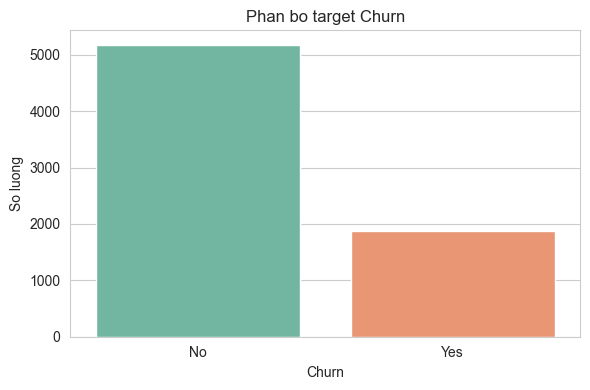

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Phan bo target Churn')
plt.xlabel('Churn')
plt.ylabel('So luong')
plt.tight_layout()

## 2. Phân phối các feature số

Dùng thống kê mô tả và biểu đồ histogram/boxplot để quan sát sự khác biệt giữa khách hàng churn và không churn.

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


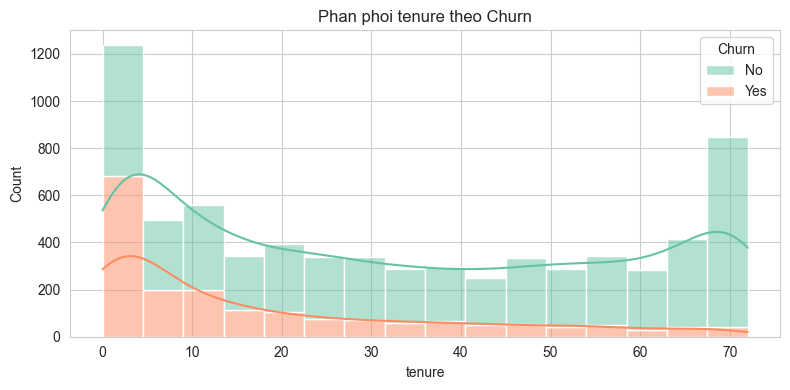

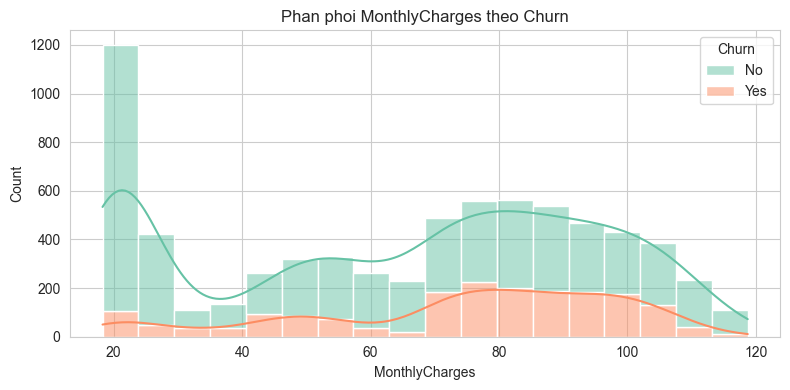

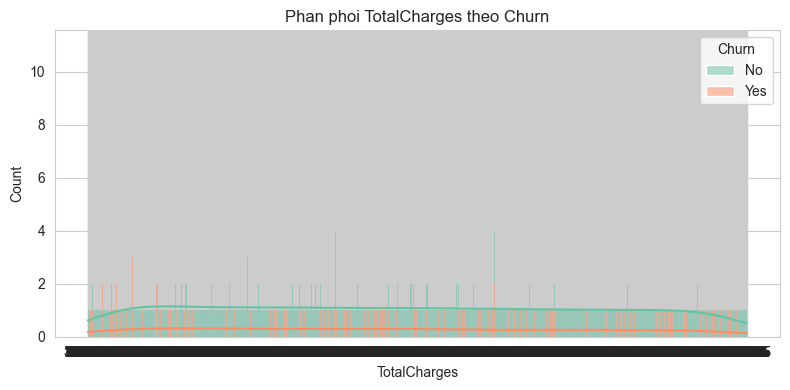

In [17]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue='Churn', kde=True, multiple='stack', palette='Set2')
    plt.title(f'Phan phoi {col} theo Churn')
    plt.tight_layout()

## 3. Phân tích tương quan

Biểu đồ heatmap cho thấy tương quan giữa các tập feature số, giúp xác định biến nào có liên quan mạnh với churn.

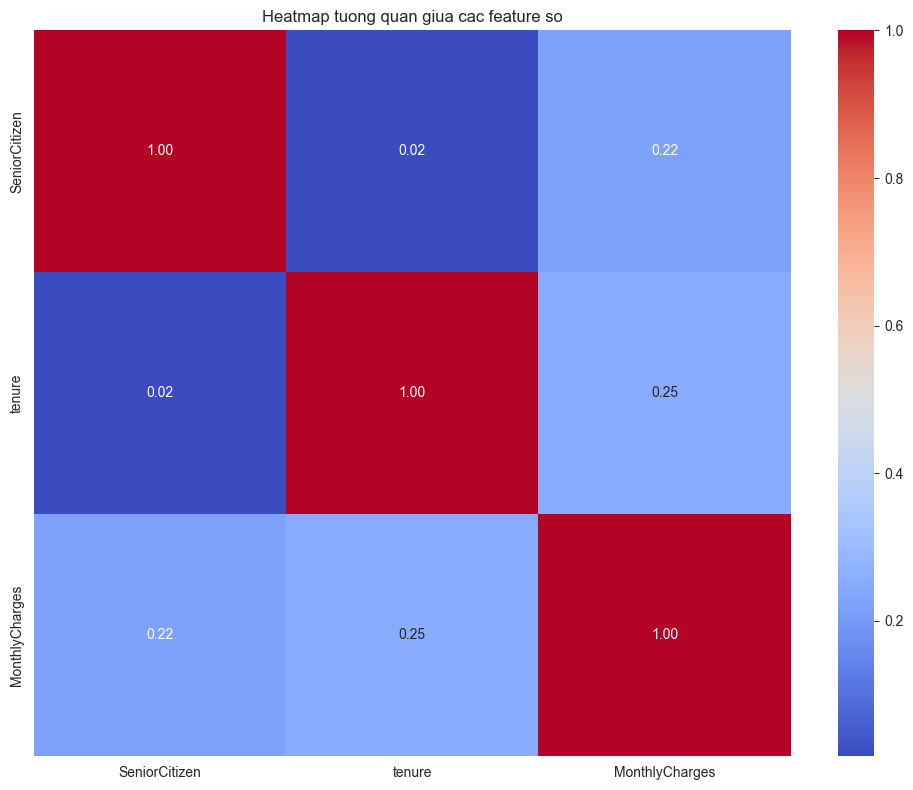

In [18]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap tuong quan giua cac feature so')
plt.tight_layout()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11972\1473512035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='Set2')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11972\1473512035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='Set2')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11972\1473512035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='Set2')


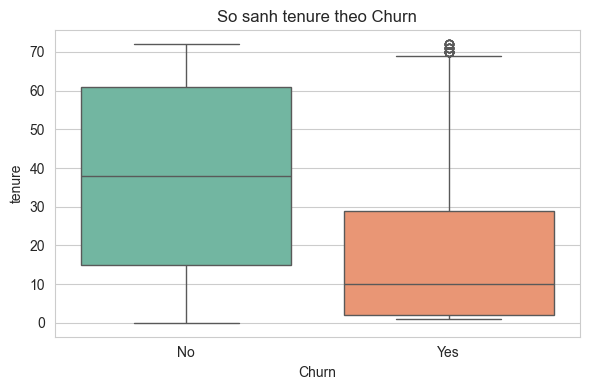

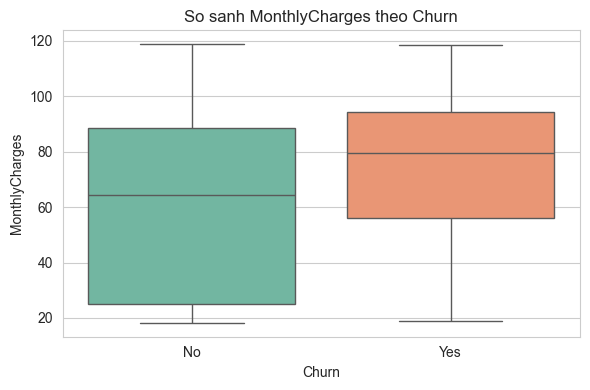

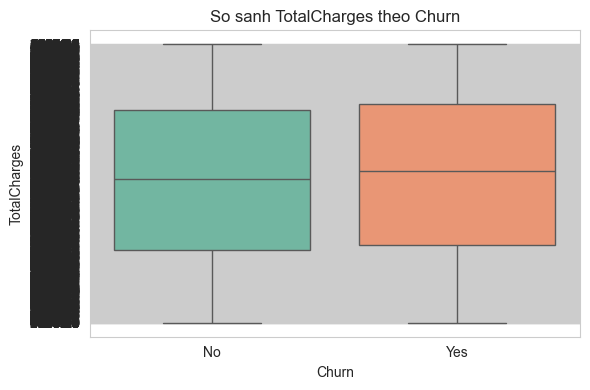

In [19]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=df, x='Churn', y=col, palette='Set2')
        plt.title(f'So sanh {col} theo Churn')
        plt.tight_layout()

## 4. Phân tích theo biến phân loại

Các biến như `Gender`, `Contract`, `InternetService`, `PaymentMethod`, `PaperlessBilling` thường có ảnh hưởng lớn tới churn.

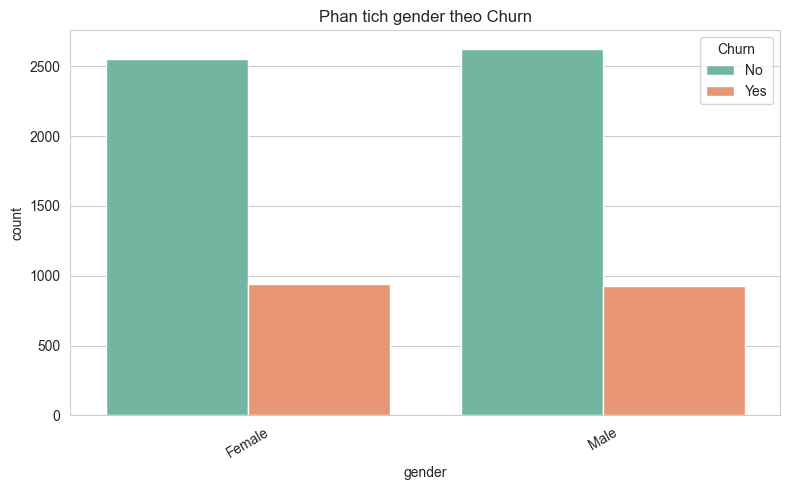

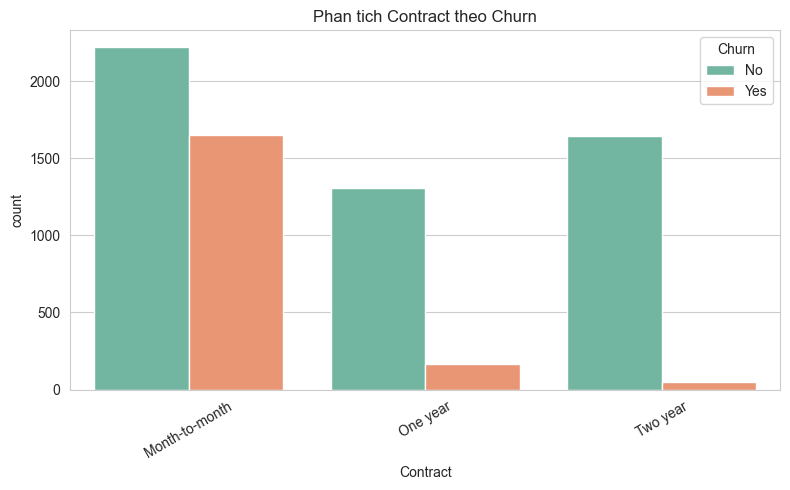

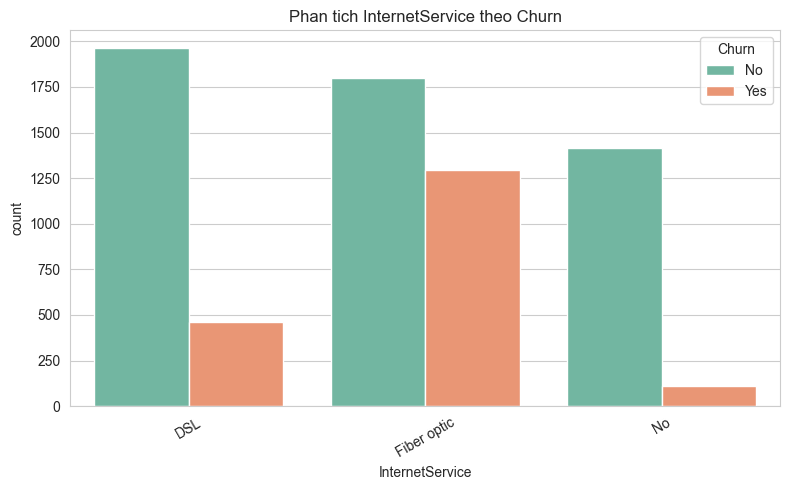

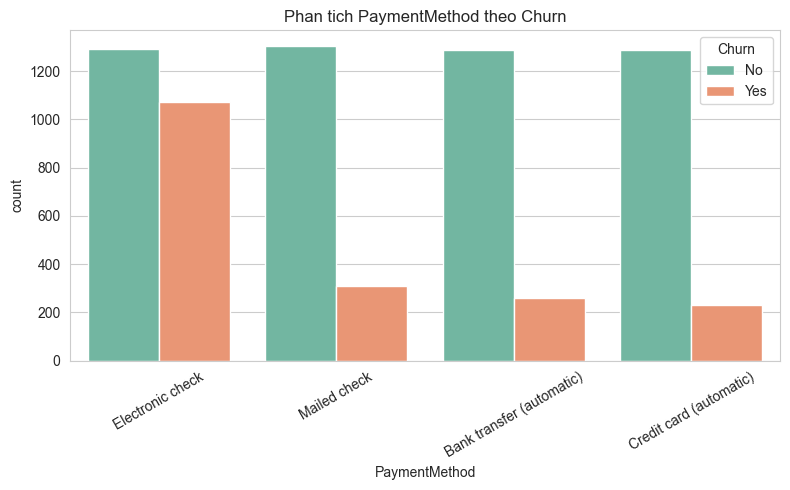

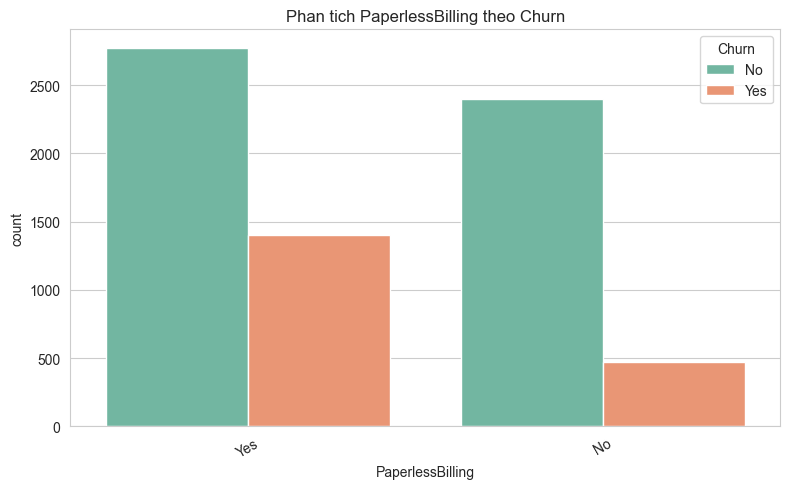

In [20]:
cat_cols = ['gender', 'Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']
for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=col, hue='Churn', palette='Set2')
        plt.title(f'Phan tich {col} theo Churn')
        plt.xticks(rotation=30)
        plt.tight_layout()